NGRC
1. The performance is not good on discrete dataset
2. Try to generate new dataset based on RK23
3. Tune the params

In [35]:
import matplotlib.pyplot as plt
import numpy as np

from reservoirpy.datasets import lorenz, doublescroll
from reservoirpy.observables import nrmse
from reservoirpy.nodes import Ridge, NVAR

from pandas import read_csv

%matplotlib inline

In [21]:
dataframe = read_csv('../3D-MLGM_dataset.csv', usecols=[0])  # get X data
dataset = dataframe.values
dataset = dataset.astype('float32')
X = dataset[:5000]
# X = 2 * (X - X.min()) / (X.max() - X.min()) - 1
warm_steps = round(0.05*len(X))
train_steps = round(0.7*len(X))
test_steps = round(0.25*len(X))

print(X)

[[ 0.1      ]
 [ 2.9878583]
 [ 2.999716 ]
 ...
 [-2.7907217]
 [-2.8492963]
 [-2.8024678]]


In [22]:
nvar = NVAR(delay=2, order=2, strides=1)
readout = Ridge(1, ridge=2.5e-6)

model = nvar >> readout
model

'Model-3': Model('NVAR-3', 'Ridge-3')

In [23]:
Xi  = X[:train_steps+warm_steps-1]
dXi = X[1:train_steps+warm_steps] - X[:train_steps+warm_steps-1]

model = model.fit(Xi, dXi, warmup=warm_steps)

Running Model-3: 3749it [00:00, 5697.55it/s]<?, ?it/s]
Running Model-3: 100%|██████████| 1/1 [00:00<00:00,  1.51it/s]


Fitting node Ridge-3...


In [33]:
nvar.run(X[warm_steps+train_steps-2:warm_steps+train_steps])
u = X[warm_steps+train_steps]
res = np.zeros((test_steps, readout.output_dim))
for i in range(test_steps):
    u = u + model(u)
    res[i, :] = u
print(len(res))

Running NVAR-3: 100%|██████████| 2/2 [00:00<00:00, 3597.17it/s]


1250


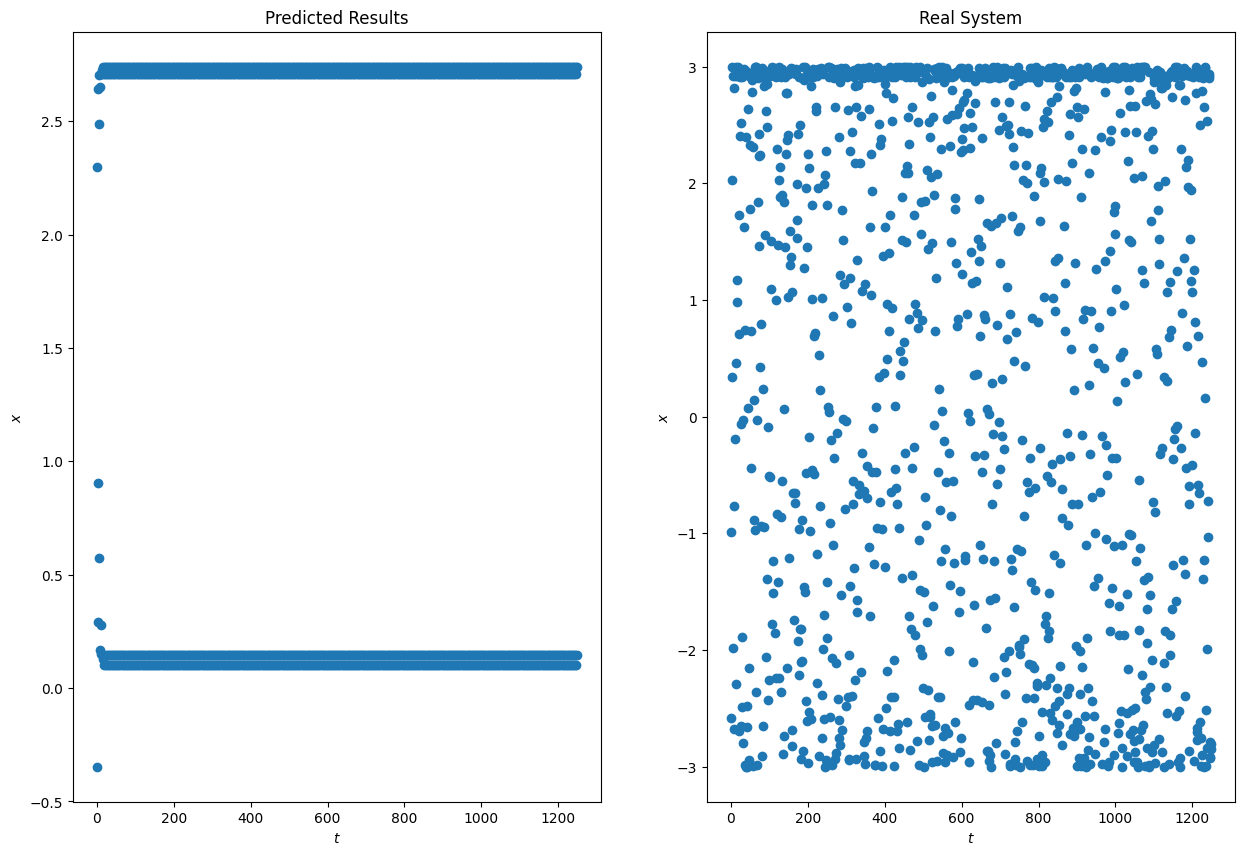

In [34]:
N = np.arange(test_steps)
Y = X[warm_steps+train_steps:]

# print(N, Y)


fig = plt.figure(figsize=(15, 10))
ax  = fig.add_subplot(121)
ax.set_title("Predicted Results")
ax.set_xlabel("$t$")
ax.set_ylabel("$x$")
ax.scatter(N, res)

ax2 = fig.add_subplot(122)
ax2.set_title("Real System")
ax2.set_xlabel("$t$")
ax2.set_ylabel("$x$")
ax2.scatter(N, Y)